In [1]:
from pathlib import Path

import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import jax.numpy as jnp

from src.distribution import ParetoDistribution, PointMass, Mixture, LinearTransform
from src.sequence import VDCSchedule

sns.set_theme(
    "paper",
    "ticks",
    font_scale=1.1,
    rc={
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "text.color": "#000000",
        "axes.labelcolor": "#000000",
        "xtick.color": "#000000",
        "ytick.color": "#000000",
    },
)
sns.set_palette("muted")

SAVE_PATH = Path("results")
SAVE_PATH.mkdir(exist_ok=True)

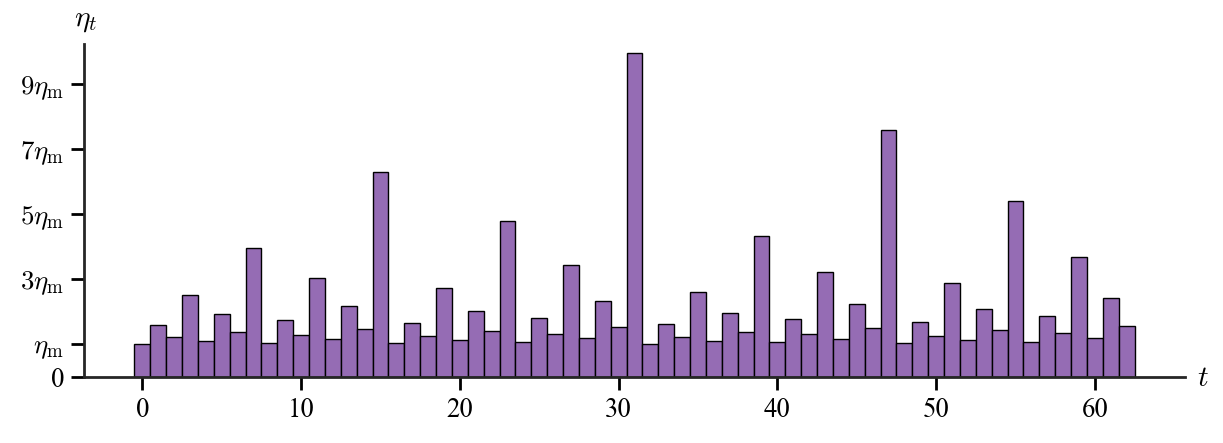

In [2]:
dist = ParetoDistribution(scale=1.0, shape=1.51)
schedule = VDCSchedule(dist)
# Use 2^6 - 1 points so the dyadic van der Corput pattern is visible.
n_to_plot = 63
ys = schedule(n_to_plot).stepsize
xs = list(range(n_to_plot))

fig, ax = plt.subplots(figsize=(6, 2.1), dpi=200, layout="constrained")
ax.bar(
    xs,
    ys,
    width=1.0,
    color="#956cb4",
    align="center",
    edgecolor="black",
    linewidth=0.5,
)
ax.set_xlabel(r"$t$", loc="right", labelpad=-21)
ax.xaxis.label.update({"x": 1.022})
ax.set_ylabel(r"$\eta_t$", rotation=0, loc="top", labelpad=-28)
ax.yaxis.label.update({"y": 1.03})

ax.xaxis.set_tick_params(pad=2.5)

# Tick labels are expressed in units of the Pareto scale eta_m.
y_tick_values = np.array([0, 1, 3, 5, 7, 9])
y_tick_labels = ["0"] + [
    rf"${i if i > 1 else ''}\eta_\mathrm{{m}}$" for i in y_tick_values[1:]
]
ax.yaxis.set_tick_params(pad=2.5)
ax.set_yticks(y_tick_values, labels=y_tick_labels)
ax.set_ylim(0, max(ys) + 0.3)
sns.despine()
plt.savefig(
    SAVE_PATH / "vdc_schedule.pdf",
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
)
plt.show()

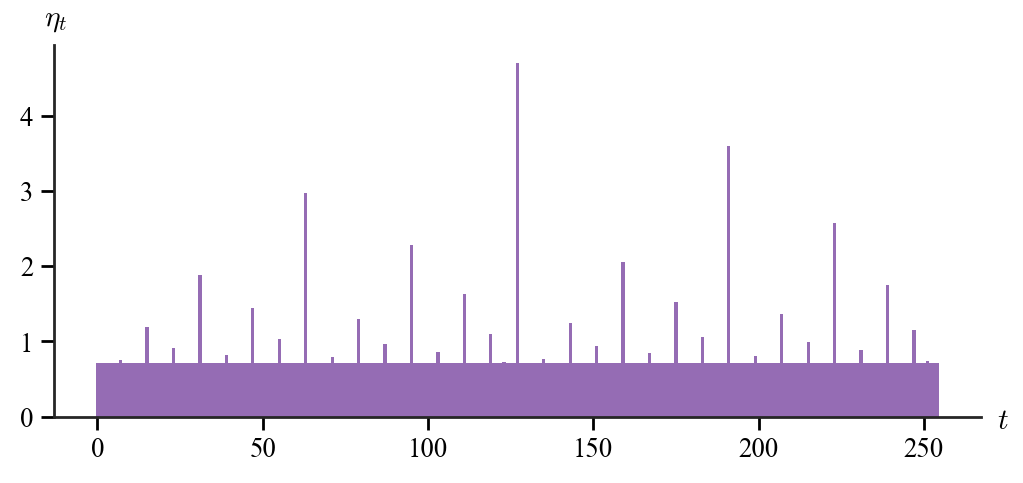

In [3]:
base_stepsize = jnp.sqrt(0.5)
sseg_beta = 1 / 0.66
sseg_mixture_p = (2 - sseg_beta) / (2 + sseg_beta)
sseg_distribution = Mixture(
    (PointMass(base_stepsize), ParetoDistribution(base_stepsize, sseg_beta)),
    weights=(1 - sseg_mixture_p, sseg_mixture_p),
)

schedule = VDCSchedule(sseg_distribution)
# Use 2^6 - 1 points so the dyadic van der Corput pattern is visible.
n_to_plot = 256-1
ys = schedule(n_to_plot).stepsize
xs = list(range(n_to_plot))

fig, ax = plt.subplots(figsize=(5, 2.3), dpi=200, layout="constrained")
ax.bar(
    xs,
    ys,
    width=1.0,
    color="#956cb4",
    align="center",
    edgecolor="black",
    linewidth=0,
)
ax.set_xlabel(r"$t$", loc="right", labelpad=-20)
ax.xaxis.label.update({"x": 1.03})
ax.set_ylabel(r"$\eta_t$", rotation=0, loc="top", labelpad=-17)
ax.yaxis.label.update({"y": 1.03})

ax.xaxis.set_tick_params(pad=2.5)
ax.yaxis.set_tick_params(pad=2.5)
sns.despine()
plt.savefig(
    SAVE_PATH / "vdc_schedule_mixture.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
)
plt.show()